In [ ]:
!pip install langdetect --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from langdetect import detect

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

All libraries imported successfully!


In [ ]:
from google.colab import drive
import os
import shutil

mount_point = '/content/drive'

if os.path.ismount(mount_point):
    print(f"'{mount_point}' is already a mount point. Unmounting...")
    try:
        drive.flush_and_unmount()
        print("Successfully unmounted Google Drive.")
    except Exception as e:
        print(f"Error unmounting: {e}")


if os.path.exists(mount_point) and not os.path.ismount(mount_point):
    print(f"Removing existing '{mount_point}' directory...")
    try:
        shutil.rmtree(mount_point)
        print("Successfully removed directory.")
    except Exception as e:
        print(f"Error removing directory: {e}")


if not os.path.exists(mount_point):
    os.makedirs(mount_point)
    print(f"Created empty directory '{mount_point}'.")


print("Attempting to mount Google Drive...")
drive.mount(mount_point, force_remount=True)
print("Google Drive mounted successfully!")

'/content/drive' is already a mount point. Unmounting...
Successfully unmounted Google Drive.
Created empty directory '/content/drive'.
Attempting to mount Google Drive...
Mounted at /content/drive
Google Drive mounted successfully!


In [ ]:
sms_data = {
    'text': [
        # ENGLISH PHISHING SMS
        "Your eSewa account has been suspended. Verify now: esewa-verify-np.com",
        "URGENT: Your Khalti wallet will be blocked. Click: khalti-secure.info",
        "Congratulations! You won Rs 5000 eSewa cashback. Claim: esewa-offer.net",
        "Dear user your eSewa password expires today. Update: esewa-login.xyz",
        "Security alert: Unusual login detected on Khalti. Verify: khalti-check.com",
        "Your eSewa KYC is incomplete. Complete now or account blocked: kyc-esewa.com",
        "Free Rs 1000 added to your Khalti! Activate now: khalti-free1000.net",
        "eSewa system upgrade. Re-login required: esewa-upgrade.info/login",
        "Your Khalti transaction failed. Retry here: khalti-retry.xyz",
        "Account verification needed for eSewa. Click: verify-esewa-np.com",
        "WARNING: Your eSewa linked bank account compromised. Secure now: esewa-bank-secure.com",
        "Khalti offers 50% cashback today only. Redeem: khalti-cashback-np.net",
        "eSewa customer support: Your refund pending. Claim: esewa-refund.info",
        "Your Khalti PIN needs reset immediately: khalti-pinreset.com/reset",
        "FINAL WARNING: eSewa account deletion in 24hrs. Save account: esewa-save.xyz",

        # NEPALI PHISHING SMS
        "Tapainko eSewa account band huncha. Abhi verify garnuhos: esewa-np-verify.com",
        "Khalti wallet suspend huncha. Turant click garnuhos: khalti-verify.info",
        "Badhai chha! Tapainle Rs 2000 eSewa ma jitnu bhayo. Claim: esewa-prize.net",
        "eSewa security alert: Tapainko account hack bhayo. Surakshit garnuhos: esewa-secure.xyz",
        "Tapainko Khalti KYC adhurik chha. Pura garnuhos: khalti-kyc-np.com",
        "eSewa le Rs 500 cashback dinchha. Abhi linus: esewa-cashback-np.net",
        "Khalti account verify nagare band huncha: khalti-account-verify.com",
        "Tapainko eSewa PIN expire bhayo. Nayi PIN rakhnus: esewa-pin-update.info",
        "SARKAR SUCHANA: Tapainko Khalti account freeze bhayo: khalti-unfreeze.xyz",
        "eSewa ma nayi feature aayo. Update garnuhos: esewa-update-np.com/login",
        "Tapainko eSewa ma Rs 1000 pending chha. Receive garnuhos: esewa-pending.net",
        "Khalti free recharge dindaichha. Claim garnuhos: khalti-recharge-free.com",
        "eSewa bank link verify garnuhos: esewa-bank-link.xyz/verify",
        "Tapainko Khalti password change garnus turant: khalti-password.info",
        "eSewa account permanently band nahun claim garnuhos: esewa-claim-np.com",

        # ENGLISH LEGITIMATE SMS
        "Your eSewa payment of Rs 500 to Ncell was successful. TXN ID: TXN20241201",
        "Rs 1000 received in your eSewa wallet from +977-98XXXXXXXX",
        "Khalti: Your mobile recharge of Rs 100 to 98XXXXXXXX was successful",
        "eSewa: Your bank transfer of Rs 5000 to NIC Asia is being processed",
        "Your Khalti KYC has been verified successfully. You can now send up to Rs 1 lakh",
        "eSewa: OTP for your transaction is 456789. Valid for 5 minutes. Do not share",
        "Khalti: Rs 200 cashback credited to your wallet. Valid till 31 Dec 2024",
        "eSewa: Your electricity bill payment of Rs 1500 was successful. Ref: EB123456",
        "Your eSewa account login was detected from Pokhara at 2:34 PM",
        "Khalti: Your internet payment of Rs 750 to Worldlink was successful",
        "eSewa support: Your complaint TKT-789 has been resolved. Check app for details",
        "Rs 300 transferred from your eSewa to +977-97XXXXXXXX successfully",
        "Khalti: Your insurance premium of Rs 2000 paid successfully to Shikhar Insurance",
        "eSewa: Monthly statement ready. Log in to app to view transactions",
        "Khalti wallet balance: Rs 1250.00 as of 01 Dec 2024",

        # NEPALI LEGITIMATE SMS
        "Tapainko eSewa ma Rs 500 prapta bhayo. TXN ID: ES20241201001",
        "Khalti bata Rs 1000 Ncell recharge safalta purwak bhayo",
        "Tapainko eSewa payment Rs 800 NTC ko lagi safal bhayo",
        "eSewa: Tapainko bank transfer Rs 3000 process bhaidaichha",
        "Khalti: Tapainko KYC safalta purwak verify bhayo",
        "eSewa OTP: 789012. 5 minute samma valid. Kasaisanga share nagarnuhos",
        "Tapainko Khalti ma Rs 150 cashback credit bhayo",
        "eSewa: Bijuli bill Rs 2200 safalta purwak tiriyeko chha. Ref: EB456",
        "Khalti: Rs 500 tapainko wallet ma transfer bhayo +977-98XXXXXXXX bata",
        "eSewa: Tapainko complaint resolve bhayo. App ma check garnuhos",
        "Khalti internet bill Rs 900 Vianet ko lagi safal bhayo",
        "Tapainko eSewa account Pokhara bata 3:45 PM ma login bhayo",
        "eSewa: Tapainko monthly statement ready chha. App ma login garnuhos",
        "Khalti balance: Rs 2150.00 — 01 Dec 2024 ko sthiti anusar",
        "eSewa bima premium Rs 1800 Prabhu Life ko lagi safal bhayo",
    ],
    'label': [1] * 30 + [0] * 30,
    'language': ['english'] * 15 + ['nepali'] * 15 + ['english'] * 15 + ['nepali'] * 15,
    'type': ['sms'] * 60
}

df_sms = pd.DataFrame(sms_data)
print(f"SMS Dataset shape: {df_sms.shape}")
print(f"\nLabel distribution:\n{df_sms['label'].value_counts()}")
print(f"\nLanguage distribution:\n{df_sms['language'].value_counts()}")

SMS Dataset shape: (60, 4)

Label distribution:
label
1    30
0    30
Name: count, dtype: int64

Language distribution:
language
english    30
nepali     30
Name: count, dtype: int64


In [ ]:
url_data = {
    'text':[
        #Phising Urls
        "http://esewa-verify-np.com/login",
        "http://khalti-secure-verify.info/account",
        "http://esewa-offer-free.net/cashback",
        "http://khalti-np-login.xyz/verify",
        "http://192.168.1.1/esewa/login",
        "http://esewa-bank-link-verify.com",
        "http://khalti-free-recharge.net/claim",
        "http://esewa-kyc-update.info/user",
        "http://www.khalti-cashback-np.net/redeem",
        "http://esewa-account-secure.xyz/update",
        "http://nepali-esewa-verify.com/pin",
        "http://khalti-prize-claim.net/winner",
        "http://esewa-login-update.info",
        "http://khalti-unfreeze-account.xyz",
        "http://esewa-np-cash.net/free",
        "http://khalti-support-help.info/reset",
        "http://verify-esewa-wallet.com/kyc",
        "http://esewa-refund-process.xyz",
        "http://khalti-account-np-verify.net",
        "http://esewa-free-money.info/claim",
        "http://khalti-security-update.xyz/login",
        "http://esewa-upgrade-now.net/account",
        "http://np-khalti-verify.com/secure",
        "http://esewa-prize-winner.net/redeem",
        "http://khalti-pin-reset-np.info",

        #Legitimate Urls
        "https://esewa.com.np/home/index",
        "https://khalti.com/login",
        "https://imepay.com.np/",
        "https://nabilbank.com/home",
        "https://nicasiabank.com",
        "https://esewa.com.np/home/faq",
        "https://khalti.com/cashout/",
        "https://esewa.com.np/mobile/recharge",
        "https://khalti.com/payment/electricity",
        "https://esewa.com.np/home/contact",
        "https://www.khalti.com/blog",
        "https://esewa.com.np/home/kyc",
        "https://khalti.com/support",
        "https://esewa.com.np/home/privacy",
        "https://khalti.com/terms",
        "https://esewa.com.np/home/about",
        "https://khalti.com/merchant",
        "https://esewa.com.np/home/insurance",
        "https://khalti.com/flight",
        "https://esewa.com.np/home/topup",
        "https://khalti.com/wallet",
        "https://esewa.com.np/home/bank-transfer",
        "https://khalti.com/utility",
        "https://esewa.com.np/home/statement",
        "https://khalti.com/profile",
    ],
    'label':[
        # Phishing (25)
        1,1,1,1,1,1,1,1,1,1,1,1,1,
        1,1,1,1,1,1,1,1,1,1,1,1,
        # Legitimate (25)
        0,0,0,0,0,0,0,0,0,0,0,0,0,
        0,0,0,0,0,0,0,0,0,0,0,0,
    ],
    'language':['both'] * 50,
    'type':['url'] * 50
}
df_url = pd.DataFrame(url_data)
print(f"URL Dataset shape: {df_url.shape}")
print(f"\nLabel distribution:\n{df_url['label'].value_counts()}")

URL Dataset shape: (50, 4)

Label distribution:
label
1    25
0    25
Name: count, dtype: int64


Folder ready!
Combined dataset shape: (110, 4)

Overall label distribution:
label
1    55
0    55
Name: count, dtype: int64

Type distribution:
type
sms    60
url    50
Name: count, dtype: int64

Language distribution:
language
both       50
english    30
nepali     30
Name: count, dtype: int64


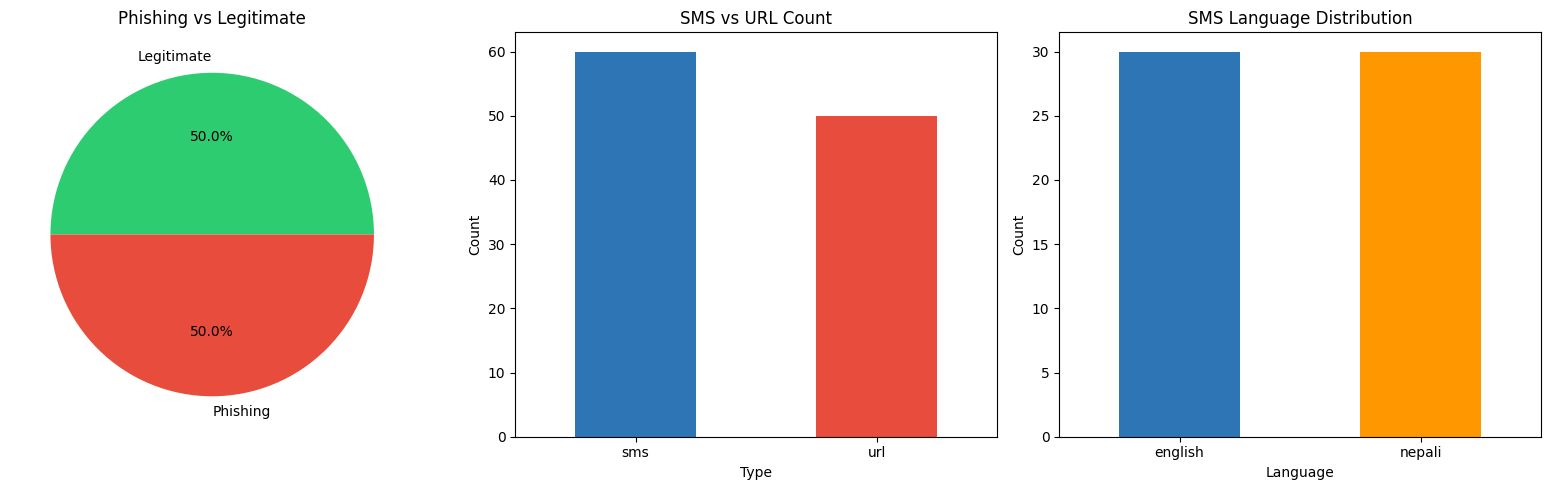

Chart saved!


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/phishing-detection',exist_ok = True)
print("Folder ready!")
df = pd.concat([df_sms, df_url], ignore_index = True)

print(f"Combined dataset shape: {df.shape}")
print(f"\nOverall label distribution:\n{df['label'].value_counts()}")
print(f"\nType distribution:\n{df['type'].value_counts()}")
print(f"\nLanguage distribution:\n{df['language'].value_counts()}")

fig,axes = plt.subplots(1,3, figsize=(16,5))

df['label'].value_counts().plot.pie(
    ax=axes[0],
    labels = ['Legitimate','Phishing'],
    autopct = '%1.1f%%',
    colors = ['#2ecc71', '#e74c3c'],
    ylabel =''
)
axes[0].set_title('Phishing vs Legitimate')

df['type'].value_counts().plot.bar(
    ax = axes[1],
    color=['#2E75B6','#e74c3c']
)
axes[1].set_title('SMS vs URL Count')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis = 'x', rotation=0)

df[df['type']=='sms']['language'].value_counts().plot.bar(
    ax = axes[2],
    color = ['#2E75b6', '#FF9800']
)
axes[2].set_title('SMS Language Distribution')
axes[2].set_xlabel('Language')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis = 'x', rotation=0)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/phishing-detection/dataset_distribution.png', dpi=150)
plt.show()
print("Chart saved!")

In [ ]:
PHISHING_KEYWORDS = [
    #English
    'verify', 'suspended','blocked', 'urgent', 'immediately',
    'claim', 'free', 'winner', 'congratulations', 'warning',
    'expire', 'update', 'secure',
    #Nepali
    'Badhai','jitnu','surakshit','banda','sarkar'
]

def preprocess_text(text):
  """
  Clean and normalize text for ML processing.
  Works for both English and Nepali text.
  """
  text = text.lower()

  text = re.sub(r'https\S+|www\S+','PHISHING_URL', text)

  text = re.sub(r'\+?\d[\d\s\-]{8,}','PHONE_NUM', text)

  text = re.sub(r'\b[A-Z]{2,}\d{4,}\b','TRANS_ID', text)

  text = re.sub(r'rs\.?\s*\d+','MONEY_AMT', text)

  text = text.translate(str.maketrans('', '', string.punctuation))

  text = ' '.join(text.split())

  return text

def extract_text_features(text):
  """
  Extract hand-crafted features from text.
  These capture phishing patterns beyond bag-of-words.
  """
  text_lower = text.lower()
  original_text = text

  features = {
      'text_length': len(text),
      'word_count': len(text.split()),
      'avg_word_length': np.mean([len(w) for w in text.split()]) if text.split() else 0,

      'has_url': int(bool(re.search(r'http|www|\.com|\.net|\.xyz|\.info',text_lower))),
      'url_count': len(re.findall(r'http\S+|www\S+', text_lower)),
      'has_suspicious_tld': int(bool(re.search(r'\.xyz|\.info|\.net(?!work)|\.click', text_lower))),
      'has_ip_address': int(bool(re.search(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', text))),
      'has_http_not_https': int('http://' in text_lower and 'https://' not in text_lower),


      'has_urgency_words':    int(any(w in text_lower for w in
                                ['urgent', 'immediately', 'turanta', 'ahile', 'now', 'today', 'warning'])),
      'has_threat_words':     int(any(w in text_lower for w in
                                ['blocked', 'suspended', 'banda', 'deleted', 'freeze', 'expire'])),
      'has_reward_words':     int(any(w in text_lower for w in
                                ['free', 'winner', 'prize', 'cashback', 'congratulations', 'badhai', 'jitnu'])),
      'has_action_words':     int(any(w in text_lower for w in
                                ['click', 'verify', 'claim', 'update', 'login', 'garnuhos'])),

      'phishing_keyword_count': sum(1 for kw in PHISHING_KEYWORDS if kw in text_lower),

      'digit_count': sum(c.isdigit() for c in text),
      'uppercase_ratio': sum(c.isupper() for c in text) / max(len(text), 1),
      'exclamation_count': text.count('!')
      }
  return features

df['text_clean'] = df['text'].apply(preprocess_text)

feature_dicts = df['text'].apply(extract_text_features).tolist()
df_hand_features = pd.DataFrame(feature_dicts)

print("Preprocessing complete!")
print(f"\nCleaned text example:")
print(f"Original: {df['text'].iloc[0]}")
print(f"Cleaned: {df['text_clean'].iloc[0]}")
print(f"\nHand_crafted features shape:{df_hand_features.shape}")
print(f"\Feature names: {df_hand_features.columns.tolist()}")

Preprocessing complete!

Cleaned text example:
Original: Your eSewa account has been suspended. Verify now: esewa-verify-np.com
Cleaned: your esewa account has been suspended verify now esewaverifynpcom

Hand_crafted features shape:(110, 16)
\Feature names: ['text_length', 'word_count', 'avg_word_length', 'has_url', 'url_count', 'has_suspicious_tld', 'has_ip_address', 'has_http_not_https', 'has_urgency_words', 'has_threat_words', 'has_reward_words', 'has_action_words', 'phishing_keyword_count', 'digit_count', 'uppercase_ratio', 'exclamation_count']


<>:78: SyntaxWarning: invalid escape sequence '\F'
<>:78: SyntaxWarning: invalid escape sequence '\F'
/tmp/ipykernel_4665/3601385674.py:78: SyntaxWarning: invalid escape sequence '\F'
  print(f"\Feature names: {df_hand_features.columns.tolist()}")


In [ ]:
def extract_url_features(url):
  """
  Extract numerical features from a URL.
  These features help detect phishing URLs.
  """
  url_lower = url.lower()

  try:
    domain = url_lower.split('/')[2] if '/' in url_lower else url_lower
  except:
    domain = url_lower

  features = {
      'url_length': len(url),
      'domain_length': len(domain),
      'path_length': len(url) - len(domain),

      'num-dots': url.count('.'),
      'num-hyphens': url.count('-'),
      'num-slashes': url.count('/'),
      'num_digits_in_domain': sum(c.isdigit() for c in domain),
      'num_subdomains': max(domain.count('.')-1,0),

      'has_https': int(url_lower.startswith('https')),
      'has_http': int(url_lower.startswith('http://')),
      'has_ip_address': int(bool(re.search(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', url))),

      'has_suspicious_tld': int(bool(re.search(r'\.xyz|\.info|\.info|\.click|\.tk|\.ml|\.ga',url_lower))),
      'has_brand_in_subdomain': int(any(brand in domain.split('.')[0]
                                  for brand in ['esewa', 'khalti', 'ncell', 'ntc','bank']
                                  if domain.count('.')>1)),
      'has_verify_in_url': int('verify' in url_lower),
      'has_login_in_url': int('login' in url_lower),
      'has_secure_in_url': int('secure' in url_lower),
      'has_update_in_url': int('update' in url_lower),
      'has_free_in_url': int('free' in url_lower),
      'has_prize_in_url': int(any(w in url_lower for w in ['prize','winner','cashback','claim'])),

      'is_official_domain': int(any(url_lower. __contains__(d)
                                for d in ['esewa.com.np', 'khalti.com', 'imepay.com.np', 'nabilbank.com'])),
      }
  return features

url_mask = df['type'] == 'url'
url_feature_dicts = df[url_mask]['text'].apply(extract_url_features).tolist()
df_url_features = pd.DataFrame(url_feature_dicts)

print("URL feature extraction complete!")
print(f"\nURL features shape: {df_url_features.shape}")
print(f"\nSample URL features:")
print(df_url_features.head(2).T)

URL feature extraction complete!

URL features shape: (50, 20)

Sample URL features:
                         0   1
url_length              32  40
domain_length           19  25
path_length             13  15
num-dots                 1   1
num-hyphens              2   2
num-slashes              3   3
num_digits_in_domain     0   0
num_subdomains           0   0
has_https                0   0
has_http                 1   1
has_ip_address           0   0
has_suspicious_tld       0   1
has_brand_in_subdomain   0   0
has_verify_in_url        1   1
has_login_in_url         1   0
has_secure_in_url        0   1
has_update_in_url        0   0
has_free_in_url          0   0
has_prize_in_url         0   0
is_official_domain       0   0


In [ ]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

df_sms_only = df[df['type'] == 'sms'].copy().reset_index(drop=True);
df_hand_sms = df_hand_features[df['type'] == 'sms'].reset_index(drop=True);

tfidf_sms = TfidfVectorizer(
    max_features=3000,
    ngram_range = (1,2),
    analyzer = 'word',
    min_df = 1,
    sublinear_tf = True,

);
X_sms_tfidf = tfidf_sms.fit_transform(df_sms_only['text_clean']);

X_sms_hand = csr_matrix(df_hand_sms.values);
X_sms = hstack([X_sms_tfidf, X_sms_hand]);
y_sms = df_sms_only['label'].values;

print(f"SMS feature matrix shape: {X_sms.shape}");
print(f"SMS labels shape:{y_sms.shape}");

df_url_only = df[df['type']=='url'].copy().reset_index(drop=True);
X_url = csr_matrix(df_url_features.values);
y_url = df_url_only['label'].values;

print(f"\nURL feature matrix shape: {X_url.shape}");
print(f"URL labels shape: {y_url.shape}");

SMS feature matrix shape: (60, 654)
SMS labels shape:(60,)

URL feature matrix shape: (50, 20)
URL labels shape: (50,)


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

X_sms_train, X_sms_test,y_sms_train,y_sms_test = train_test_split(
    X_sms, y_sms,
    test_size = 0.2,
    random_state = 42,
    stratify = y_sms
)

sms_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
    }
sms_results ={}

print("\n" + "=" *  50)
print("SMS PHISHING DETECTION RESULTS")
print("="*50)

for name, model in sms_models.items():
  print(f"\nTraining {name}...")
  model.fit(X_sms_train, y_sms_train)
  y_pred = model.predict(X_sms_test)
  y_prob = model.predict_proba(X_sms_test)[:,1]

  auc = roc_auc_score(y_sms_test, y_prob)
  report = classification_report(y_sms_test, y_pred, output_dict=True)

  sms_results[name] = {
      'AUC-ROC': round(auc,4),
      'Precision': round(report['1']['precision'],4),
      'Recall': round(report['1']['recall'],4),
      'F1-Score': round(report['1']['f1-score'],4),
      'Accuracy': round(accuracy_score(y_sms_test, y_pred),4),
  }
  print(f"AUC-ROC: {auc:.4f}")
  print(classification_report(y_sms_test, y_pred, target_names=['Legitimate','Phishing']))

sms_results_df = pd.DataFrame(sms_results).T
print("\n=== SMS MODEL COMPARISON ===")
print(sms_results_df)


SMS PHISHING DETECTION RESULTS

Training Logistic Regression...
AUC-ROC: 1.0000
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00         6
    Phishing       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12


Training Random Forest...
AUC-ROC: 0.9722
              precision    recall  f1-score   support

  Legitimate       0.83      0.83      0.83         6
    Phishing       0.83      0.83      0.83         6

    accuracy                           0.83        12
   macro avg       0.83      0.83      0.83        12
weighted avg       0.83      0.83      0.83        12


Training XGBoost...
AUC-ROC: 1.0000
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00         6
    Phishing       1.00      1.00      1.00         6

    accuracy         

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:19:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
X_url_train, X_url_test, y_url_train, y_url_test = train_test_split(
    X_url, y_url,
    test_size = 0.2,
    random_state = 42,
    stratify = y_url
)

print(f"URL Train: {X_url_train.shape[0]} | Test: {X_url_test.shape[0]}")

url_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=1000, random_state=42,n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss',use_label_encoder=False)
}
url_results = {}
print("\n"+"="*50)
print("URL PHISHING DETECTION RESULTS")
print("="*50)

for name, model in url_models.items():
  print(f"\nTraining{name}...")
  model.fit(X_url_train, y_url_train)
  y_pred = model.predict(X_url_test)
  y_prob = model.predict_proba(X_url_test)[:,1]

  auc = roc_auc_score(y_url_test, y_prob)
  report = classification_report(y_url_test, y_pred, output_dict=True)

  url_results[name]={
      'AUC-ROC': round(auc, 4),
      'Precision': round(report['1']['precision'],4),
      'Recall': round(report['1']['recall'],4),
      'F1-Score': round(report['1']['f1-score'],4)
  }

  print(f"AUC-ROC: {auc:.4f}")
  print(classification_report(y_url_test, y_pred, target_names = ['Legitimate','Phishing']))

  url_results_df = pd.DataFrame(url_results).T
  print("\n=== URL MODEL COMPARISION ===")
  print(url_results_df)

URL Train: 40 | Test: 10

URL PHISHING DETECTION RESULTS

TrainingLogistic Regression...
AUC-ROC: 1.0000
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00         5
    Phishing       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


=== URL MODEL COMPARISION ===
                     AUC-ROC  Precision  Recall  F1-Score
Logistic Regression      1.0        1.0     1.0       1.0

TrainingRandom Forest...
AUC-ROC: 1.0000
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00         5
    Phishing       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


=== URL MODEL COMPARISION ===
                     

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:19:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC-ROC: 1.0000
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00         5
    Phishing       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


=== URL MODEL COMPARISION ===
                     AUC-ROC  Precision  Recall  F1-Score
Logistic Regression      1.0        1.0     1.0       1.0
Random Forest            1.0        1.0     1.0       1.0
XGBoost                  1.0        1.0     1.0       1.0


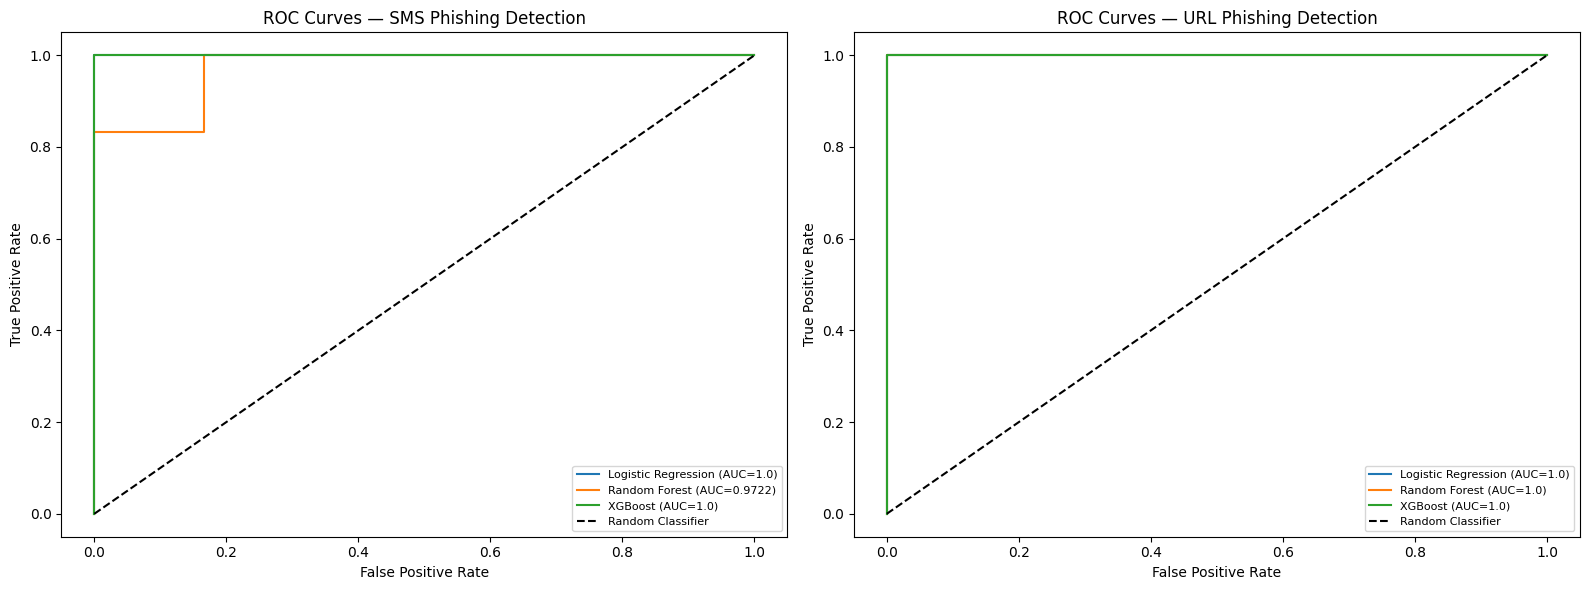

ROC curves saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#SMS ROC Curves
for name, model in sms_models.items():
    y_prob    = model.predict_proba(X_sms_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_sms_test, y_prob)
    auc       = sms_results[name]['AUC-ROC']
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc})')

axes[0].plot([0,1], [0,1], 'k--', label='Random Classifier')
axes[0].set_title('ROC Curves — SMS Phishing Detection')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)

#URL ROC Curves
for name, model in url_models.items():
    y_prob    = model.predict_proba(X_url_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_url_test, y_prob)
    auc       = url_results[name]['AUC-ROC']
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc})')

axes[1].plot([0,1], [0,1], 'k--', label='Random Classifier')
axes[1].set_title('ROC Curves — URL Phishing Detection')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/phishing-detection/roc_curves.png', dpi=150)
plt.show()
print("ROC curves saved!")

In [ ]:
from google.colab import drive

#FINAL COMBINED RESULTS TABLE
print("="*60)
print("FINAL RESULTS — SMS PHISHING DETECTION")
print("="*60)
print(pd.DataFrame(sms_results).T.to_string())

print("\n" + "="*60)
print("FINAL RESULTS — URL PHISHING DETECTION")
print("="*60)
print(pd.DataFrame(url_results).T.to_string())

#LANGUAGE-SPECIFIC ANALYSIS
print("\n" + "="*60)
print("LANGUAGE-SPECIFIC ANALYSIS (English vs Nepali)")
print("="*60)

best_sms_model_name = max(sms_results, key=lambda x: sms_results[x]['F1-Score'])
best_sms_model = sms_models[best_sms_model_name]

# Get test indices
sms_test_idx = df_sms_only.index[
    pd.Series(range(len(df_sms_only))).isin(
        range(int(len(df_sms_only)*0.8), len(df_sms_only))
    )
]

# Predict on all SMS data
y_all_pred = best_sms_model.predict(X_sms)
df_sms_only['predicted'] = y_all_pred
df_sms_only['correct']   = (df_sms_only['predicted'] == df_sms_only['label']).astype(int)

# Accuracy by language
lang_accuracy = df_sms_only.groupby('language')['correct'].mean()
print(f"\nBest model ({best_sms_model_name}) accuracy by language:")
for lang, acc in lang_accuracy.items():
    print(f"  {lang.capitalize()}: {acc*100:.1f}%")


pd.DataFrame(sms_results).T.to_csv(
    '/content/drive/MyDrive/phishing-detection/sms_results.csv')
pd.DataFrame(url_results).T.to_csv(
    '/content/drive/MyDrive/phishing-detection/url_results.csv')

print("\nAll results saved to Google Drive!")
print("\n Phishing detection research complete!")
print(f"Best SMS model: {max(sms_results, key=lambda x: sms_results[x]['F1-Score'])}")
print(f"Best URL model: {max(url_results, key=lambda x: url_results[x]['F1-Score'])}")

FINAL RESULTS — SMS PHISHING DETECTION
                     AUC-ROC  Precision  Recall  F1-Score  Accuracy
Logistic Regression   1.0000     1.0000  1.0000    1.0000    1.0000
Random Forest         0.9722     0.8333  0.8333    0.8333    0.8333
XGBoost               1.0000     1.0000  1.0000    1.0000    1.0000

FINAL RESULTS — URL PHISHING DETECTION
                     AUC-ROC  Precision  Recall  F1-Score
Logistic Regression      1.0        1.0     1.0       1.0
Random Forest            1.0        1.0     1.0       1.0
XGBoost                  1.0        1.0     1.0       1.0

LANGUAGE-SPECIFIC ANALYSIS (English vs Nepali)

Best model (Logistic Regression) accuracy by language:
  English: 100.0%
  Nepali: 100.0%

All results saved to Google Drive!

 Phishing detection research complete!
Best SMS model: Logistic Regression
Best URL model: Logistic Regression


In [ ]:
import os

drive_path = '/content/drive/MyDrive/phishing-detection/'

print(f"Contents of {drive_path}:")
if os.path.exists(drive_path):
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"The directory {drive_path} does not exist in the Colab environment.")

Contents of /content/drive/MyDrive/phishing-detection/:
Phising.ipynb
dataset_distribution.png
roc_curves.png
sms_results.csv
url_results.csv
dummy_test_file.txt
